# Análisis de cambio semánticos (generar datos para análisis)

In [1]:
# Importar librería
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import pickle
import os
import re
import random as rn
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bootstrap
import matplotlib.pyplot as plt
import itertools

from gensim.models import Word2Vec
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
tqdm.pandas()

from ast import literal_eval

In [2]:
# Configurar
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
modelo_dir =  RESULTADOS_DIR+ '/archivos_out/modelos_swmwosge_1008211100'
pd.set_option('display.max_colwidth', None)

Se selecciona para analizar el modelo de procrustes

In [3]:
basename = 'procrustes'
iteracion = 50
tam_vector = 100

In [4]:
# estabilidad_procrustes_iter10_tam50
selected_topics_df = pd.read_csv(
    modelo_dir+'/estabilidad_procrustes/estabilidad_'+basename+'_iter'+str(iteracion)+'_tam'+str(tam_vector)+'.csv',
    converters={'par_periodo': literal_eval})

selected_topics_df.head(5)

,iteracion,par_periodo,palabra,similaridad_semantica,cantidad_palabras_comun,top10_vecindad_t1,top10_vecindad_t2
0,34,"(2009, 2014)",declaracion,0.139084,632,"[('jujuy', 0.6815905570983887), ('valle', 0.6574221849441528), ('rioja', 0.6136496067047119), ('natural', 0.6101409792900085), ('accion', 0.607310950756073), ('epidemiologico', 0.5931129455566406), ('chaco', 0.58115553855896), ('departamento', 0.5785106420516968), ('vital', 0.5667181611061096), ('isla', 0.5567507743835449)]","[('prepagar', 0.6978649497032166), ('valor', 0.6527655124664307), ('marco', 0.6332517266273499), ('suspension', 0.620722234249115), ('listado', 0.5737744569778442), ('medicina', 0.5715073347091675), ('maternidad', 0.5679755210876465), ('comision', 0.5671313405036926), ('requisito', 0.5650686025619507), ('inssjp', 0.5496528744697571)]"
1,8,"(2014, 2019)",dispositivo,0.140859,461,"[('nocivo', 0.741174042224884), ('electronico', 0.6656293869018555), ('similar', 0.6375887393951416), ('necesario', 0.5919848680496216), ('transgenico', 0.5645980834960938), ('correspondiente', 0.5506635904312134), ('dato', 0.5495872497558594), ('efecto', 0.5474739670753479), ('leches', 0.5464898943901062), ('medicamentosa', 0.5459393262863159)]","[('tecnologico', 0.6496908068656921), ('minimo', 0.6148243546485901), ('subitar', 0.5806657075881958), ('desfibrilador', 0.5703412890434265), ('concurrencia', 0.5692965984344482), ('oftalmologico', 0.5578402280807495), ('instalacion', 0.549335241317749), ('pobreza', 0.48999667167663574), ('cartel', 0.4870681166648865), ('comprendido', 0.4805179834365845)]"
2,35,"(2009, 2014)",declaracion,0.142975,632,"[('jujuy', 0.6613746881484985), ('valle', 0.6454302072525024), ('rioja', 0.6270276308059692), ('accion', 0.6161777377128601), ('natural', 0.5990722179412842), ('departamento', 0.5819897651672363), ('vital', 0.5772116780281067), ('plazo', 0.5743117332458496), ('chaco', 0.5708519220352173), ('epidemiologico', 0.5534880757331848)]","[('prepagar', 0.7063223123550415), ('valor', 0.6669445633888245), ('suspension', 0.6285974979400635), ('marco', 0.611617922782898), ('comision', 0.6020828485488892), ('medicina', 0.5939154624938965), ('listado', 0.5737608671188354), ('inssjp', 0.5706518888473511), ('requisito', 0.5444856286048889), ('afiliado', 0.5432479381561279)]"
3,49,"(2014, 2019)",dispositivo,0.156437,461,"[('nocivo', 0.7533208131790161), ('electronico', 0.7043081521987915), ('similar', 0.6479951739311218), ('dato', 0.6144565939903259), ('necesario', 0.5826627016067505), ('efecto', 0.5824446082115173), ('leches', 0.566091001033783), ('digital', 0.5574067234992981), ('transgenico', 0.5546780228614807), ('receta', 0.5503663420677185)]","[('tecnologico', 0.667518138885498), ('minimo', 0.6108192801475525), ('subitar', 0.5848939418792725), ('desfibrilador', 0.5503489375114441), ('concurrencia', 0.538344144821167), ('oftalmologico', 0.5293062329292297), ('instalacion', 0.5183323621749878), ('examen', 0.4997488260269165), ('aplicacion', 0.4990216791629791), ('gratuito', 0.49481597542762756)]"
4,16,"(2014, 2019)",dispositivo,0.157902,461,"[('nocivo', 0.7413178086280823), ('electronico', 0.6455979943275452), ('similar', 0.6439734101295471), ('necesario', 0.5787308216094971), ('dato', 0.5661934018135071), ('correspondiente', 0.565628707408905), ('efecto', 0.5564053654670715), ('digital', 0.5451880693435669), ('transgenico', 0.5420355200767517), ('receta', 0.5396386981010437)]","[('tecnologico', 0.6254727840423584), ('minimo', 0.6207189559936523), ('subitar', 0.5933816432952881), ('oftalmologico', 0.5582135319709778), ('concurrencia', 0.5575965046882629), ('instalacion', 0.5537137389183044), ('desfibrilador', 0.5419023036956787), ('examen', 0.5076811909675598), ('cartel', 0.49721089005470276), ('comprendido', 0.4896608591079712)]"


In [5]:
selected_topics_df.describe() # Estadística

,iteracion,similaridad_semantica,cantidad_palabras_comun
count,54650.000000,54650.000000,54650.000000
mean,24.500000,0.660539,559.876487
std,14.431002,0.137234,84.447914
min,0.000000,0.139084,461.000000
25%,12.000000,0.573016,461.000000
50%,24.500000,0.672693,632.000000
75%,37.000000,0.759678,632.000000
max,49.000000,0.951906,632.000000


Se realizaron 50 ejecuciones independientes del enfoque Procrustes, cada una con una semilla aleatoria distinta. En cada iteración, se seleccionaron las 300 palabras con mayor cambio semántico entre los pares de períodos comparados, considerando únicamente aquellas con al menos 5 ocurrencias en alguno de los dos períodos de cinco años.

Posteriormente, se calculó la similaridad semantica promedio (medida de estabilidad del modelo) para cada palabra identificada en cada par de periodos comparados. Este valor fue estimado junto con sus respectivos intervalos de confianza del 95%, utilizando el método bootstrap.

In [6]:
n = 300
at_least_in_any_decade = 5
pares_periodo = [ (2009, 2014),(2014, 2019)]
topn_periodo = {}

for par_periodo in pares_periodo:
    df =  selected_topics_df[
        selected_topics_df['par_periodo'] == par_periodo
    ].copy()
    
    
    frecPer1 = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[0])+'.csv')
    frecPer2 = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[1])+'.csv')
    frecPer1.columns = ['palabra', 'frec1', 'porc1']
    frecPer2.columns = ['palabra', 'frec2', 'porc2']
    #print(frecPer2.shape)
    topn_all_df = []

    for iter in range(iteracion):
        #print(iter)
        df_topn = df[(df.iteracion==iter)]
        #controlar frec
        #display(df_topn)
        df_topn = df_topn.merge(frecPer1, how='left', on='palabra')
        df_topn = df_topn.merge(frecPer2, how='left', on='palabra')
        df_topn['max_freq_of_any_decade'] = df_topn[['frec1', 'frec2']].max(axis=1)
        df_topn.drop(['frec1', 'frec2', 'porc1', 'porc2'], axis=1, inplace=True) 
        df_topn = df_topn.loc[df_topn.max_freq_of_any_decade>= at_least_in_any_decade].head(n)
        df_topn = df_topn.sort_values('similaridad_semantica', ascending=True).head(n)
        #display(df_topn)
        topn_all_df.append(df_topn)
    
    topn_periodo[par_periodo] = pd.concat(topn_all_df, ignore_index=True)    


#### Intersección promedio
Por el enfoque Procruste para cada par de periodos de 5 años:
¿Cuál es la similaridad semantica promedio (medida de estabilidad del modelo) de los top 300 palabras de las 50 ejecuciones para cada par de periodos comparados con intervalos de confianza del 95% calculados mediante el método bootstrap? 


In [7]:
def confidence_intervals(data):
    res = bootstrap((data,), np.mean, confidence_level=0.95)
    return (res.confidence_interval.low, res.confidence_interval.high)

In [8]:
topn_periodo_all = topn_periodo.copy() # copiar

In [9]:
#df = topn_periodo[(2009, 2014)].copy()
#data = df['palabra'].value_counts().reset_index()
#data = data[data['count']<2]
#pal_lista = list(data['palabra'].unique())
#pal_lista
# (2009, 2014) = ['tratamiento',  'provincia',  'desastre',  'celula', 'pmo', 'ministerio', 'zona', 'ambito']
#(2014, 2019) = ['nina', 'persona', 'medicina', 'potable', 'ley']

In [10]:
for par_periodo in pares_periodo: 
    display(topn_periodo[par_periodo].shape)
    df = topn_periodo[par_periodo].copy()
    data = df['palabra'].value_counts().reset_index()
    data = data[data['count']>=2]
    pal_lista = list(data['palabra'].unique())
    df = df[df['palabra'].isin(pal_lista)]
    df['vt1'] = df['top10_vecindad_t1'].apply(lambda x: [ peso[0] for peso in eval(x) ])
    df['vt2'] = df['top10_vecindad_t2'].apply(lambda x: [ peso[0] for peso in eval(x) ])
    df['vt1_union'] = df['vt1'].copy()
    df['vt2_union'] = df['vt2'].copy()
    
    #df = df[['par_periodo', 'palabra', 'similaridad_semantica']].groupby(['par_periodo', 'palabra']).agg(['mean', confidence_intervals]).reset_index()
    df = df[['par_periodo', 'palabra', 'similaridad_semantica','vt1','vt2','vt1_union','vt2_union']].groupby(['par_periodo', 'palabra']).agg({
        'similaridad_semantica': ['mean',confidence_intervals],
        'vt1': [ lambda listas: set.intersection(*map(set, listas))],
        'vt2': [ lambda listas: set.intersection(*map(set, listas))],
        'vt1_union': [ lambda listas: set.union(*map(set, listas))],
        'vt2_union': [ lambda listas: set.union(*map(set, listas))]
    }).reset_index()

    #df.sort_values(by='par_periodo', inplace=True)
    df.columns = [
    '_'.join(filter(None, x))
    for x in df.columns.to_flat_index() 
    ]
     	
    df.rename(columns={'vt1_<lambda>': 'vt1_top10', 'vt2_<lambda>': 'vt2_top10','vt1_union_<lambda>': 'vt1_top10_union', 'vt2_union_<lambda>': 'vt2_top10_union'}, inplace=True)
    topn_periodo[par_periodo] = df

    
  
  


(15000, 8)

(15000, 8)

In [11]:
topn_periodo[par_periodo].head(3)

,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10,vt1_top10_union,vt2_top10_union
0,"(2014, 2019)",accesibilidad,0.313364,"(0.3017256484604389, 0.3256906090258448)","{discapacitada, consentimiento, movilidad}","{gestion, digno, elemento, trabajo, dato}","{judicial, consentimiento, multiple, beneficio, concurrencia, hijo, espacio, discapacitada, area, fertilizacion, extension, informado, equinoterapia, movilidad, poblacion, actualizacion, automatico, permanente, maternidad, garantizar, trasplantado}","{calendario, gestion, etiqueta, celiaca, banco, tabaco, tecnologico, atrofia, pension, numerir, gratuito, tumor, condicion, producto, espinal, muscular, digno, ame, fumar, oftalmologico, congenita, gluten, ambiental, elemento, elaborado, trabajo, dato}"
1,"(2014, 2019)",acceso,0.620647,"(0.6099290370338003, 0.630174479920783)","{potable, comercialicir, solar, formulacion, epidemiologico, sal, consumar}","{presupuesto, prioritario}","{potable, solar, piercing, perforacion, padecer, formulacion, relacionado, cartel, sal, agua, radiacion, consumar, subitar, comercialicir, comida, exhibicion, biomedico, epidemiologico, lugar, asistido, medida, gasificado}","{potable, autorizar, necesario, minimo, proteina, apto, padecer, acv, reproduccion, vacuna, agua, presupuesto, universal, farmacia, medicamento, punto, manejo, garantizar, aplv, departamento, privado, prioritario}"
2,"(2014, 2019)",accidente,0.578996,"(0.5721264212077553, 0.5858361335599931)","{cerebrovascular, acv, sustancia, acvo, vascular}","{alzheimer, cerebrovascular, acv}","{cerebrovascular, acv, caso, presupuesto, sustancia, acvo, natural, mancha, vino, rehabilitacion, artriti, oporto, reumatoidea, vida, juegos, vascular, exposicion}","{psicologico, malformacion, calendario, cerebrovascular, proteina, quimico, atrofia, adiccion, acv, alzheimer, alergia, mancha, llamado, vino, leyenda, muscular, artriti, oporto, ame, termino, campana, mes, regional, espinal, prevenibl, vascular}"


### Cambios semánticos  

#### Identificar las palabras con cambio semántico importante y moderado

Identificar las palabras que aparecen consistentemente como cambiantes con similitud coseno promedio inferior a 0.5
tal que: 

* Cambio fuerte  (usos muy distintos) : similitud coseno promedio <= 0.3 (umbral 1) 
* Cambio moderado: similitud coseno promedio entre 0.3 y 0.5 (umbral 2)


In [12]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convertir datos en DataFrame para visualización
def plot_heatmap(cambios_df, title, top = 10):
    #words, values = zip(*changed_words[:top])  # Tomamos el top 10
    #df = pd.DataFrame({"Palabra": words, "Cambio Semántico": values})
    df = cambios_df.copy()
    plt.figure(figsize=(8, 5))
    sns.heatmap(df.set_index("palabra").T, cmap="Reds", annot=True, fmt=".2f", linewidths=0.5)
    plt.title(title + " Top "+str(top))
    plt.show()



dist > 0.7 (sc <= 0.3) Cambio fuerte (usos muy distintos)


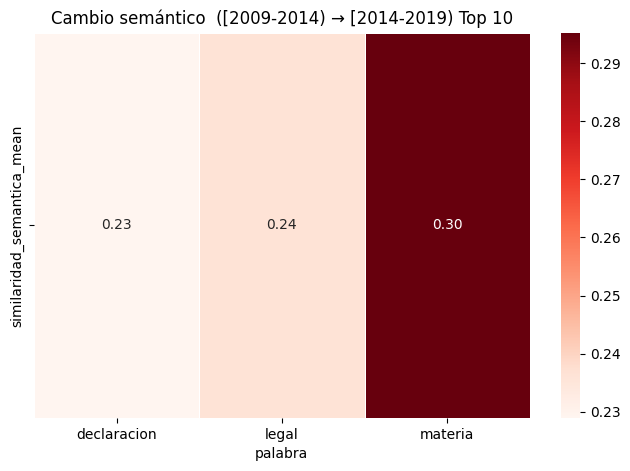

TOP 10 Palabras: ['declaracion' 'legal' 'materia']


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10,vt1_top10_union,vt2_top10_union
81,"(2009, 2014)",declaracion,0.228949,"(0.21734069298480946, 0.23947355413807772)","{valle, jujuy, accion, chaco, rioja, vital, departamento, natural}","{marco, comision, valor, prepagar, suspension}","{valle, clinico, cordoba, estr, isla, rioja, pedro, alergia, natural, jujuy, espinal, rio, ochenta, accion, epidemiologico, mendoza, plazo, chaco, vital, departamento}","{medicina, mayo, pobreza, comision, lectivo, evaluacion, valor, suspension, requisito, federal, pami, exigencia, marco, maternidad, prepagar, listado, inssjp, afiliado}"
187,"(2009, 2014)",legal,0.236390,"(0.22927847455041062, 0.24318201364083122)","{musicoterapia, auxiliar, colaborador, loteria, norma, obstetricia, odontologia}","{embarazo, misoprostol, droga, monodroga}","{musicoterapia, auxiliar, loteria, obstetricia, ejercicio, fitoterapicos, colaborador, terapeuta, expendio, terapista, eliminacion, cosmetologo, norma, capitulo, trabajador, ocupacional, odontologia}","{distribucion, calendario, recoleccion, formulacion, cirugia, fetal, mercurio, medicamento, terapia, laser, produccion, tipo, misoprostol, edad, monodroga, malformacion, medicamentosa, vencido, ftalato, realizacion, fabricacion, instrumento, droga, menor, domiciliario, fitoterapicos, planta, vegetal, aptitud, aplv, embarazo}"
198,"(2009, 2014)",materia,0.295281,"(0.28972409518941494, 0.30129455440205416)","{primaria, fortalecimiento, estr, adopcion, basica, postraumatico, presupuesto, delito}","{politica, congreso, vacunacion, laboratorio, cumplimiento}","{primaria, fortalecimiento, minimo, estr, presupuesto, basica, postraumatico, delito, objetivo, prostata, financiero, censo, adopcion, fortalecer}","{fiebre, obligacion, consentimiento, pobreza, vencido, voluntario, vacunacion, cumplimiento, agropecuario, area, politica, violencia, produccion, domiciliario, observatorio, congreso, muerte, laboratorio, economico, trabajo}"


dist ~ 0.5 (sc ~ 0.5)  Cambio moderado


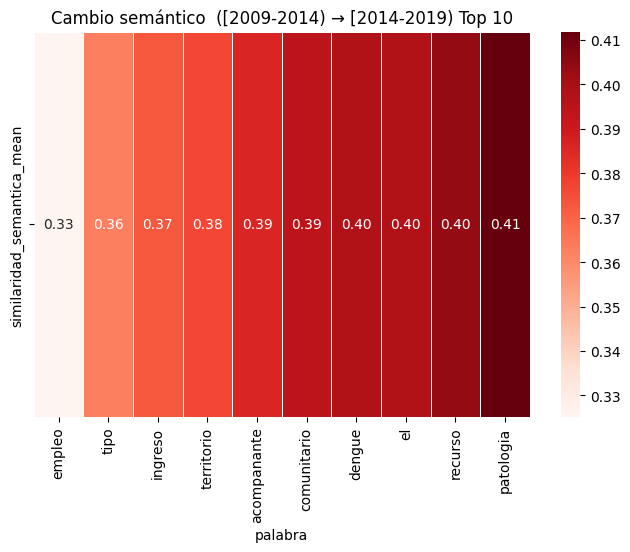

TOP 10 Palabras: ['empleo' 'tipo' 'ingreso' 'territorio' 'acompanante' 'comunitario'
 'dengue' 'el' 'recurso' 'patologia']


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10,vt1_top10_union,vt2_top10_union
118,"(2009, 2014)",empleo,0.325182,"(0.3161450291105868, 0.33453466898180717)","{nivel, familia, hogar, jefe, equivalente}","{contributivo, subsistema, ftalato, asignacion, sustancia, elemento}","{rural, remuneracion, comunitario, hogar, contencion, equivalente, formacion, nivel, consejo, familia, observatorio, jefe, monto, republica, inssjp}","{hijo, ftalato, asignacion, odontologico, sustancia, formacion, mercurio, alergena, instrumento, contributivo, oporto, primario, subsistema, elemento, monodroga}"
327,"(2009, 2014)",tipo,0.362660,"(0.35430114554481895, 0.3705464389172895)","{papiloma, h1n1, avance, virus, gripe, influenza, aparicion, causado}","{fabricacion, droga, ensenanza, cualquiera}","{papiloma, h1n1, avance, virus, asistencial, hpv, causado, incremento, neumococo, gripe, pandemia, cobro, varicela, influenza, aparicion}","{distribucion, medicamentosa, organo, vacuna, nomenclador, legal, cualquiera, mercurio, fabricacion, instrumento, droga, importacion, deportivo, ensenanza}"
176,"(2009, 2014)",ingreso,0.372726,"(0.36275331038413855, 0.383107578577557)","{ninez, anses, ciudadano, geriatrico, fincini, ganancia, basico}","{ninez, solar, virus, categoria, maquina}","{ninez, fisico, anses, ciudadano, mental, ganancia, ordenado, basico, diabetes, geriatrico, fincini}","{ninez, solar, fiebre, ciudadano, pobreza, concurrencia, virus, categoria, area, deber, federal, azar, conexa, politica, explotacion, maquina, sancion, manejo}"
326,"(2009, 2014)",territorio,0.376451,"(0.36559694072614785, 0.38760333407996167)","{corriente, tintoreria, percloroetileno, reconocer, lavanderia, aparicion}","{restaurante, republica, natural}","{corriente, dengue, isla, reconocer, causado, represa, ochenta, tintoreria, percloroetileno, lavanderia, chaco, aparicion}","{restaurante, etiqueta, tecnologico, jugo, inundacion, ocurrido, reparacion, comision, alcohol, juego, natural, importacion, similar, argentina, maquina, porcentaje, menu, codigo, perjudicial, republica, afiliado}"
4,"(2009, 2014)",acompanante,0.385782,"(0.3796140793051261, 0.3927100810180494)","{recien, gratuidad, proceso, parto, permanencia, embarazo, nacimiento}","{piercing, recurso, perforacion, equinoterapia, cosmetologia, terapeutico, obstetricia, cosmiatrio}","{consultoria, mistanasica, colegio, recien, gratuidad, proceso, reconstruccion, permanencia, nacido, nacimiento, violencia, puerperio, primario, mujer, embarazo, parto, situacion, maternidad, relacion, privado}","{piercing, recurso, perforacion, tatuaj, tecnico, obstetricia, ejercicio, cosmiatrio, equinoterapia, cosmetologia, terapeutico}"
65,"(2009, 2014)",comunitario,0.394368,"(0.3854192976683241, 0.40313915747436657)","{sanitaria, militar, direccion, hogar, voluntario, radicacion, revestir}","{familia, financiero, accion, julio, marzo}","{sanitaria, adiccion, hogar, voluntario, revestir, empleo, militar, direccion, familia, observatorio, jefe, monto, radicacion}","{fortalecimiento, primaria, adiccion, mayo, febrero, mental, comision, natural, familia, desarrollo, mes, maternidad, enfermo, odontologia, doctor, organismo, ninez, medicina, paliativo, julio, prestacion, valor, marzo, digno, financiero, marco, accion, enero}"
84,"(2009, 2014)",dengue,0.397421,"(0.3906659951600832, 0.40396962671954595)","{territorio, ochenta, epidemia, seguimiento, emergente, chaco, tropical, aparicion}","{nosocomial, fiebre, virus, comprendido}","{cordoba, epidemia, emergente, demencia, tropical, medioambiental, causado, territorio, sanitario, represa, ochenta, prioritario, seguimiento, chaco, aparicion}","{ninez, nosocomial, fiebre, intrahospitalaria, cerebrovascular, virus, comprendido, paliativo, vacuna, lectivo, vacunacion, tumor, alzheimer, pediculosis, digno, transcurso, nocivo}"
111,"(2009, 2014)",el,0.397509,"(0.38912091958821676, 0.4055441278858894)","{infeccion, septiembre, juvenil, inf

dist > 0.7 (sc <= 0.3) Cambio fuerte (usos muy distintos)


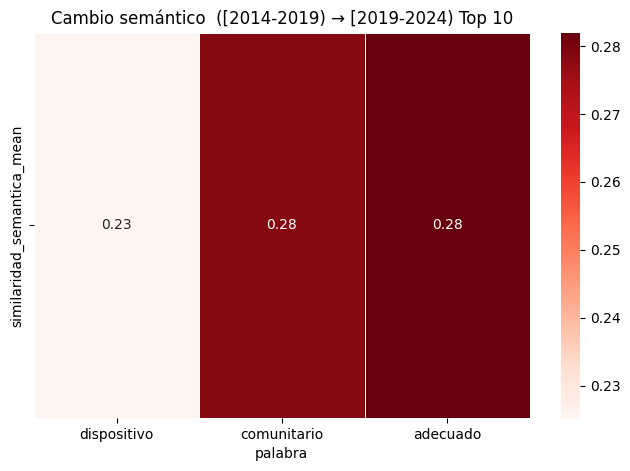

TOP 10 Palabras: ['dispositivo' 'comunitario' 'adecuado']


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10,vt1_top10_union,vt2_top10_union
102,"(2014, 2019)",dispositivo,0.225310,"(0.21517525682306737, 0.23474702168764897)","{similar, electronico, dato, necesario, nocivo}","{desfibrilador, minimo, tecnologico, instalacion, concurrencia, oftalmologico, subitar}","{receta, medicamentosa, leches, efecto, correspondiente, braille, implementacion, digital, comprendido, fabricacion, transgenico, electronico, similar, dato, incorporar, necesario, sufrir, nocivo}","{minimo, tecnologico, instalacion, concurrencia, pobreza, comprendido, cartel, agua, gratuito, radiacion, subitar, desfibrilador, examen, argentina, oftalmologico, lugar, aplicacion}"
68,"(2014, 2019)",comunitario,0.278242,"(0.27209223779084657, 0.28498834537825385)","{familia, financiero, accion, julio, marzo}","{fortalecimiento, reconocimiento, agente, trabajador, escolar, presupuesto, organizacion, objeto}","{fortalecimiento, primaria, adiccion, mayo, febrero, mental, comision, natural, familia, desarrollo, mes, maternidad, enfermo, odontologia, doctor, organismo, ninez, medicina, paliativo, julio, prestacion, valor, marzo, digno, financiero, marco, accion, enero}","{reconocimiento, fortalecimiento, corporal, modificatoria, cuyo, agente, grasa, escolar, presupuesto, organizacion, obstetricia, asignacion, tumor, objeto, comida, estetico, trabajador, complejidad}"
5,"(2014, 2019)",adecuado,0.281939,"(0.27380922948631065, 0.29072955279423457)","{medicinal, especialidad, rotulacion, camara}","{hijo, congreso, paliativo, geriatrico, tumor, manejo}","{medicinal, potable, jugo, alimentario, modificatoria, especialidad, camara, profesion, alcohol, frio, cadena, composicion, farmaceutico, capitulo, porcentaje, guarderia, codigo, circuito, television, rotulacion, gasificado}","{modificatoria, hijo, ejecutivo, paliativo, nomenclador, agente, tumor, pais, procreacion, digno, diabetes, congreso, funcion, geriatrico, mama, provincial, situacion, manejo, dato}"


dist ~ 0.5 (sc ~ 0.5)  Cambio moderado


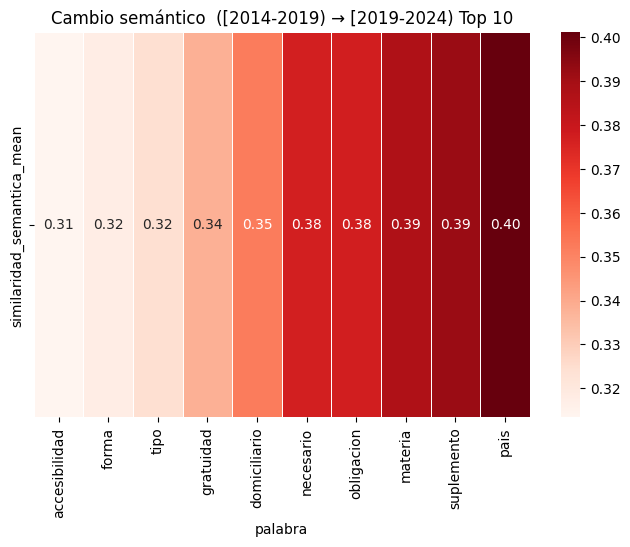

TOP 10 Palabras: ['accesibilidad' 'forma' 'tipo' 'gratuidad' 'domiciliario' 'necesario'
 'obligacion' 'materia' 'suplemento' 'pais']


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10,vt1_top10_union,vt2_top10_union
0,"(2014, 2019)",accesibilidad,0.313364,"(0.3017256484604389, 0.3256906090258448)","{discapacitada, consentimiento, movilidad}","{gestion, digno, elemento, trabajo, dato}","{judicial, consentimiento, multiple, beneficio, concurrencia, hijo, espacio, discapacitada, area, fertilizacion, extension, informado, equinoterapia, movilidad, poblacion, actualizacion, automatico, permanente, maternidad, garantizar, trasplantado}","{calendario, gestion, etiqueta, celiaca, banco, tabaco, tecnologico, atrofia, pension, numerir, gratuito, tumor, condicion, producto, espinal, muscular, digno, ame, fumar, oftalmologico, congenita, gluten, ambiental, elemento, elaborado, trabajo, dato}"
150,"(2014, 2019)",forma,0.317746,"(0.30709437050229627, 0.3279225069040292)","{transmision, complemento, proteina, cualquiera}","{domiciliario, correspondiente, actualizacion, modelo, organizacion}","{etiqueta, proteina, derivado, apto, adiccion, relacionado, tecnica, oximetria, gratuito, cualquiera, examen, complemento, transmision, biomedico, pulso, hospital, investigacion}","{corporal, fisico, correspondiente, modificatoria, hijo, establecido, bis, nomenclador, organizacion, publicitario, cualquiera, condicion, domiciliario, mundial, ter, actualizacion, funcion, automatico, respectivamente, modelo, trabajo}"
319,"(2014, 2019)",tipo,0.324483,"(0.31554016370582855, 0.3338127264717762)","{fabricacion, droga, ensenanza, cualquiera}","{judicial, identificacion, braille, diabetes, visual, droga}","{distribucion, medicamentosa, organo, vacuna, nomenclador, legal, cualquiera, mercurio, fabricacion, instrumento, droga, importacion, deportivo, ensenanza}","{judicial, identificacion, braille, visual, tecnica, capacidad, condicion, droga, diabetes, primario, animal, afectar, pensionado, secundario, sustitucion, trasplantado}"
159,"(2014, 2019)",gratuidad,0.338310,"(0.32870270818783265, 0.3475855696532716)","{vacuna, calendario, vacunacion}","{potable, ter, jubilado, agua, presupuesto, pensionado}","{psicologico, calendario, fiebre, medicamentosa, administracion, venerea, ensenanza, implante, comprendido, vacunacion, vacuna, resolucion, profilaxis, paciente, estatal, radiacion, area, asiento, oftalmologico, infanto, sufrir, otorgar, juvenil}","{potable, minimo, genetico, agente, agua, presupuesto, instituto, financiero, ter, afectado, dependencia, jubilado, especial, trabajador, pensionado, publico, consecuencia, medida, afiliado}"
106,"(2014, 2019)",domiciliario,0.352300,"(0.34218341901493204, 0.3632497526569617)","{recoleccion, vencido, inssjp, resolucion}","{forma, financiero, ter, organizacion, educacion, trasplantado}","{fortalecimiento, autorizar, recoleccion, tecnologico, nosocomial, vencido, paliativo, resolucion, cadena, frio, tumor, medicamento, pami, alzheimer, deber, consejo, comercialicir, fitoterapicos, digno, planta, vegetal, jubilado, pensionado, tecnologia, secundario, inssjp}","{fisico, modificatoria, organizacion, obstetricia, cualquiera, tumor, educacion, actividad, forma, rehabilitacion, digno, equinoterapia, financiero, diabetes, ter, especial, certificado, cuidado, trabajo, trasplantado}"
226,"(2014, 2019)",necesario,0.376819,"(0.36968563011637146, 0.3837369113647057)","{dispositivo, desfibrilador, precio, concurrencia, subitar, existir}","{precio, principio, publicitario}","{concurrencia, realizacion, fetal, masivo, subitar, area, dispositivo, desfibrilador, diabetico, comida, precio, muerte, automatico, incorporar, externo, existir}","{malformacion, proteina, dengue, acv, reproduccion, publicitario, alzheimer, mancha, llamado, terapia, vino, produccion, importacion, oporto, precio, principio, grupo, misoprostol, mujer, norma, cronico, vascular, garantizar, aplv, comercializacion, manejo}"
233,"(2014, 2019)",obligacion,0.377334,"(0.3676906106188161, 0.38580297248050355)","{congreso, especialidad, profesion,

In [13]:
topk = 10
for par_periodo in pares_periodo:

    print("dist > 0.7 (sc <= 0.3) Cambio fuerte (usos muy distintos)")
    periodo_df = topn_periodo[par_periodo]
    umbral_fuerte1 = 0.3
    periodo_df1 =  periodo_df[periodo_df['similaridad_semantica_mean']<=umbral_fuerte1].sort_values('similaridad_semantica_mean', ascending=True).head(topk)
    # Graficar Heatmaps
    plot_heatmap(periodo_df1[['palabra','similaridad_semantica_mean']], "Cambio semántico  (["+str(par_periodo[0])+"-"+str(par_periodo[1])+") → ["+str(par_periodo[1])+"-"+str(par_periodo[1]+5)+")", top=topk)
    print("TOP 10 Palabras:", periodo_df1['palabra'].unique())
    display(periodo_df1) 
    print("dist ~ 0.5 (sc ~ 0.5)  Cambio moderado")

    umbral_fuerte2 = 0.5
    periodo_df1 =  periodo_df[(periodo_df['similaridad_semantica_mean']<=umbral_fuerte2) & (periodo_df['similaridad_semantica_mean']>umbral_fuerte1)].sort_values('similaridad_semantica_mean', ascending=True).head(topk)
    # Graficar Heatmaps
    plot_heatmap(periodo_df1[['palabra','similaridad_semantica_mean']], "Cambio semántico  (["+str(par_periodo[0])+"-"+str(par_periodo[1])+") → ["+str(par_periodo[1])+"-"+str(par_periodo[1]+5)+")", top=topk)
    print("TOP 10 Palabras:", periodo_df1['palabra'].unique())
    display(periodo_df1)    


In [14]:
# GUARDAR OBJETO
with open(modelo_dir+'/top300_periodos_procrustes_df.pkl', 'wb') as file: 
    pickle.dump(topn_periodo,file)

Palabras comunes entre los pares de períodos

In [15]:
# palabra común en entre períodos
palabra_comun = set(topn_periodo[(2009, 2014)]['palabra'].unique()) & set(topn_periodo[(2014, 2019)]['palabra'].unique())
print("Cantidad de palabras en común:",len(palabra_comun))

Cantidad de palabras en común: 274


Top 10

In [16]:
# Período (2009, 2014)
df = topn_periodo[(2009, 2014)]
df = df[df['palabra'].isin(palabra_comun)]
df = df[['palabra','similaridad_semantica_mean','similaridad_semantica_confidence_intervals','vt1_top10','vt2_top10']]
df.columns = ['palabra','ss_mean_2009_2014','ss_ci_2009_2014','vt1_top10_2009_2014','vt2_top10_2009_2014']
# Período (2014, 2019)
df2 = topn_periodo[(2014, 2019)]
df2 = df2[df2['palabra'].isin(palabra_comun)]
df2 = df2[['palabra','similaridad_semantica_mean','similaridad_semantica_confidence_intervals','vt1_top10','vt2_top10']]
df2.columns = ['palabra','ss_mean_2014_2019','ss_ci_2014_2019','vt1_top10_2014_2019','vt2_top10_2014_2019']
# Unión
df = df.merge(df2, how='inner', on='palabra')
df = df[['palabra', 'ss_mean_2009_2014', 'ss_mean_2014_2019', 'ss_ci_2009_2014','ss_ci_2014_2019','vt1_top10_2009_2014','vt2_top10_2009_2014', 'vt1_top10_2014_2019','vt2_top10_2014_2019']]
df['peso'] = (df['ss_mean_2009_2014'] + df['ss_mean_2014_2019'] )/2
print("Top 10 de palabras comunes con Fuerte cambio semántco entre Período [2009, 2014) - > [2014, 2019)  ")
print("Palabras:",df[df['peso']<=0.3].sort_values('peso').head(10)['palabra'].unique() )
display(df[df['peso']<=0.3].sort_values('peso').head(10))
print("Top 10 de palabras comunes con moderado cambio semántco entre Período [2009, 2014) - > [2014, 2019)  ")
print("Palabras:",df[(df['peso']>0.3) & (df['peso']<=0.5)].sort_values('peso').head(10)['palabra'].unique() )
display(df[(df['peso']>0.3) & (df['peso']<=0.5)].sort_values('peso').head(10))



Top 10 de palabras comunes con Fuerte cambio semántco entre Período [2009, 2014) - > [2014, 2019)  
Palabras: []


,palabra,ss_mean_2009_2014,ss_mean_2014_2019,ss_ci_2009_2014,ss_ci_2014_2019,vt1_top10_2009_2014,vt2_top10_2009_2014,vt1_top10_2014_2019,vt2_top10_2014_2019,peso


Top 10 de palabras comunes con moderado cambio semántco entre Período [2009, 2014) - > [2014, 2019)  
Palabras: ['comunitario' 'materia' 'tipo' 'legal' 'ingreso' 'gratuidad' 'argentina'
 'domiciliario' 'necesario' 'obligacion']


,palabra,ss_mean_2009_2014,ss_mean_2014_2019,ss_ci_2009_2014,ss_ci_2014_2019,vt1_top10_2009_2014,vt2_top10_2009_2014,vt1_top10_2014_2019,vt2_top10_2014_2019,peso
54,comunitario,0.394368,0.278242,"(0.3854192976683241, 0.40313915747436657)","(0.27209223779084657, 0.28498834537825385)","{sanitaria, militar, direccion, hogar, voluntario, radicacion, revestir}","{familia, financiero, accion, julio, marzo}","{familia, financiero, accion, julio, marzo}","{fortalecimiento, reconocimiento, agente, trabajador, escolar, presupuesto, organizacion, objeto}",0.336305
166,materia,0.295281,0.387141,"(0.28972409518941494, 0.30129455440205416)","(0.3795103875474098, 0.3947197528161688)","{primaria, fortalecimiento, estr, adopcion, basica, postraumatico, presupuesto, delito}","{politica, congreso, vacunacion, laboratorio, cumplimiento}","{politica, congreso, vacunacion, laboratorio, cumplimiento}","{vih, zona, infeccion, sexual, periodo, prorrogable}",0.341211
258,tipo,0.362660,0.324483,"(0.35430114554481895, 0.3705464389172895)","(0.31554016370582855, 0.3338127264717762)","{papiloma, h1n1, avance, virus, gripe, influenza, aparicion, causado}","{fabricacion, droga, ensenanza, cualquiera}","{fabricacion, droga, ensenanza, cualquiera}","{judicial, identificacion, braille, diabetes, visual, droga}",0.343572
156,legal,0.236390,0.544586,"(0.22927847455041062, 0.24318201364083122)","(0.5367409556444638, 0.5524675364778583)","{musicoterapia, auxiliar, colaborador, loteria, norma, obstetricia, odontologia}","{embarazo, misoprostol, droga, monodroga}","{embarazo, misoprostol, droga, monodroga}","{estetico, misoprostol, beneficiario, obstetricia, ingreso}",0.390488
147,ingreso,0.372726,0.412960,"(0.36275331038413855, 0.383107578577557)","(0.40638691279749256, 0.419535943999969)","{ninez, anses, ciudadano, geriatrico, fincini, ganancia, basico}","{ninez, solar, virus, categoria, maquina}","{ninez, solar, virus, categoria, maquina}","{fortalecimiento, indice, primario, jubilado, beneficiario, pensionado, otorgar}",0.392843
128,gratuidad,0.519763,0.338310,"(0.5108354225421323, 0.5281449193363955)","(0.32870270818783265, 0.3475855696532716)","{acompanante, indirecto, proceso, prohibir, directo, permanencia, nacimiento, rotavirus}","{vacuna, calendario, vacunacion}","{vacuna, calendario, vacunacion}","{potable, ter, jubilado, agua, presupuesto, pensionado}",0.429037
23,argentina,0.442295,0.437635,"(0.436044236520672, 0.44842712913052624)","(0.42690586000537556, 0.4475896708366713)","{cigarrillo, bioetica, riesgo, prioritario, limitacion, chagas, comercializado, republica}","{tecnologico, comision, republica, erupcion, objeto, volcan, natural, basico}","{tecnologico, comision, republica, erupcion, objeto, volcan, natural, basico}","{desfibrilador, pobreza, evaluacion, tecnologia, prevenibl, republica}",0.439965
85,domiciliario,0.530396,0.352300,"(0.5232490962499607, 0.5373275994736747)","(0.34218341901493204, 0.3632497526569617)","{recoleccion, vencido, capacidad, partos, odontologico, peligroso, mercurio, instrumento, civil}","{recoleccion, vencido, inssjp, resolucion}","{recoleccion, vencido, inssjp, resolucion}","{forma, financiero, ter, organizacion, educacion, trasplantado}",0.441348
184,necesario,0.511345,0.376819,"(0.502066570851367, 0.5204022468271262)","(0.36968563011637146, 0.3837369113647057)","{incluyendolo, ostomizada, presupuesto, olivia, medicacion}","{dispositivo, desfibrilador, precio, concurrencia, subitar, existir}","{dispositivo, desfibrilador, precio, concurrencia, subitar, existir}","{precio, principio, publicitario}",0.444082
190,obligacion,0.534139,0.377334,"(0.5251409580361376, 0.5424780460585731)","(0.3676906106188161, 0.38580297248050355)","{posibilidad, cromosomatico, willi, prader, spw, existir}","{congreso, especialidad, profesion, farmaceutico, cumplimiento}","{congreso, especialidad, profesion, farmaceutico, cumplimiento}","{sangre, judicial, animal, donante, alcoholica}",0.455736


In [17]:
# GUARDAR OBJETO
with open(modelo_dir+'/palComun_cambioSem_procrustes_df.pkl', 'wb') as file: 
    pickle.dump(df,file)

### Chat GPT

#### Breve historia del sistema argentino de salud entre 2009 a 2023

Destacando los principales cambios, políticas y desafíos en ese período:

**2009-2015: Ampliación de cobertura y enfoque en salud pública**
* Programa Nacer (iniciado antes) se transformó en Programa SUMAR (2012), ampliando la cobertura sanitaria gratuita a población sin obra social, especialmente niños, embarazadas y adultos hasta 64 años.

* Se fortalecieron las políticas de atención primaria, la distribución gratuita de medicamentos esenciales y el control de enfermedades crónicas.

* Ley Nacional de Salud Mental (2010): marcó un cambio paradigmático hacia una atención centrada en la comunidad, con foco en derechos humanos.

* Inversión en infraestructura y en redes de servicios provinciales, aunque con desigualdades persistentes entre regiones.

**2016-2019: Intento de reformas estructurales y retrocesos por la crisis**

* Lanzamiento de la Cobertura Universal de Salud (CUS) en 2016, con el objetivo de mejorar el acceso de personas sin cobertura formal; sin embargo, tuvo una implementación limitada.

* La crisis económica (inflación, devaluación, recorte del gasto) afectó recursos para salud pública y programas nacionales.

* Tensiones con obras sociales y prepagas por regulaciones, deudas y aranceles.

* En 2018, debate parlamentario por la legalización del aborto generó una movilización social histórica, aunque fue rechazado por el Senado.

**2020-2023: Pandemia, legalización del aborto y digitalización**
* COVID-19 (2020-2021) puso al sistema bajo gran presión: se ampliaron camas, respiradores, se contrató personal y se distribuyeron recursos federales.

* Se desarrolló un plan nacional de vacunación masivo y gratuito, con campañas públicas y centros de vacunación en todo el país.

* En diciembre de 2020 se aprobó la Ley 27.610 de Interrupción Voluntaria del Embarazo, garantizando el derecho a acceder a un aborto legal y seguro hasta la semana 14.

* Se fortaleció la telemedicina y se impulsó la digitalización de historiales clínicos, aunque de manera desigual según la provincia.

* En 2022-2023, el sistema volvió a enfrentar restricciones presupuestarias por la crisis económica, con reclamos de trabajadores de salud, atraso en pagos a proveedores y conflicto con prepagas por aumentos de cuotas y regulación estatal.

#### Conclusión
El sistema de salud argentino entre 2009 y 2023 mostró avances importantes en derechos y cobertura, especialmente con programas públicos y leyes clave (salud mental, aborto). Pero también atravesó crisis económicas y desafíos estructurales que afectaron la calidad y equidad del acceso, manteniéndose como un sistema fragmentado y desigual, con fuerte dependencia de decisiones políticas nacionales y provinciales.

# Anexo

#### Como detectar cambios liguistico con chatgpt

Detectar cambios lingüísticos con ChatGPT u otros modelos de lenguaje puede hacerse de varias formas, dependiendo de qué tipo de cambio te interesa (léxico, semántico, sintáctico, etc.).

* Comparación sincrónica: simular diferentes “épocas” pidiéndole al modelo que hable como si fuera de cierto año:

🗣️ Prompt:
“¿Cómo se usaba la palabra ‘cuidar’ en el contexto de salud pública en Argentina en 2010?”
vs.
“¿Cómo se usa la palabra ‘cuidar’ en el contexto de salud pública en Argentina en 2023?”

* Análisis con embeddings + ChatGPT

Asistente para interpretar cambios de significado basados en embeddings entrenados por año. Ejemplo:
Entrenás vectores (word embeddings) para distintos años. Medís distancia o cambio de contexto de ciertas palabras clave. Usás ChatGPT para ayudarte a interpretar esos cambios

🔍 Prompt:
“En 2010, la palabra ‘prevención’ estaba más cerca de ‘vacuna’, ‘campaña’, ‘dengue’. En 2023, está más cerca de ‘cuidado’, ‘género’, ‘territorio’. ¿Qué tipo de cambio semántico puede estar ocurriendo?”